# Chapter 8 — Noise & Artifacts

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch08_noise_artifacts.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch08_noise_artifacts.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch08_noise_artifacts.ipynb)

> **Motivating question.** Before removing noise, can we name it? Powerline hum, baseline sway, muscle bursts, blinks.

## What this notebook demonstrates

- Noise colours: white, pink (1/f), brown; PSD slope
- Powerline interference and its harmonics
- Impulsive / salt-and-pepper noise; baseline wander & motion
- Quality control BEFORE preprocessing
- Diagnose the noise before choosing the tool

## What you'll do

You'll build a noise "line-up" (white/pink/brown) and classify each by its PSD slope, then identify powerline interference and impulsive/salt-and-pepper artifacts by their signatures before picking a fix.

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | full (synthetic data, NumPy/SciPy/sklearn only) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
from scipy.signal import welch

CH = 8

## 8.1  noise lineup

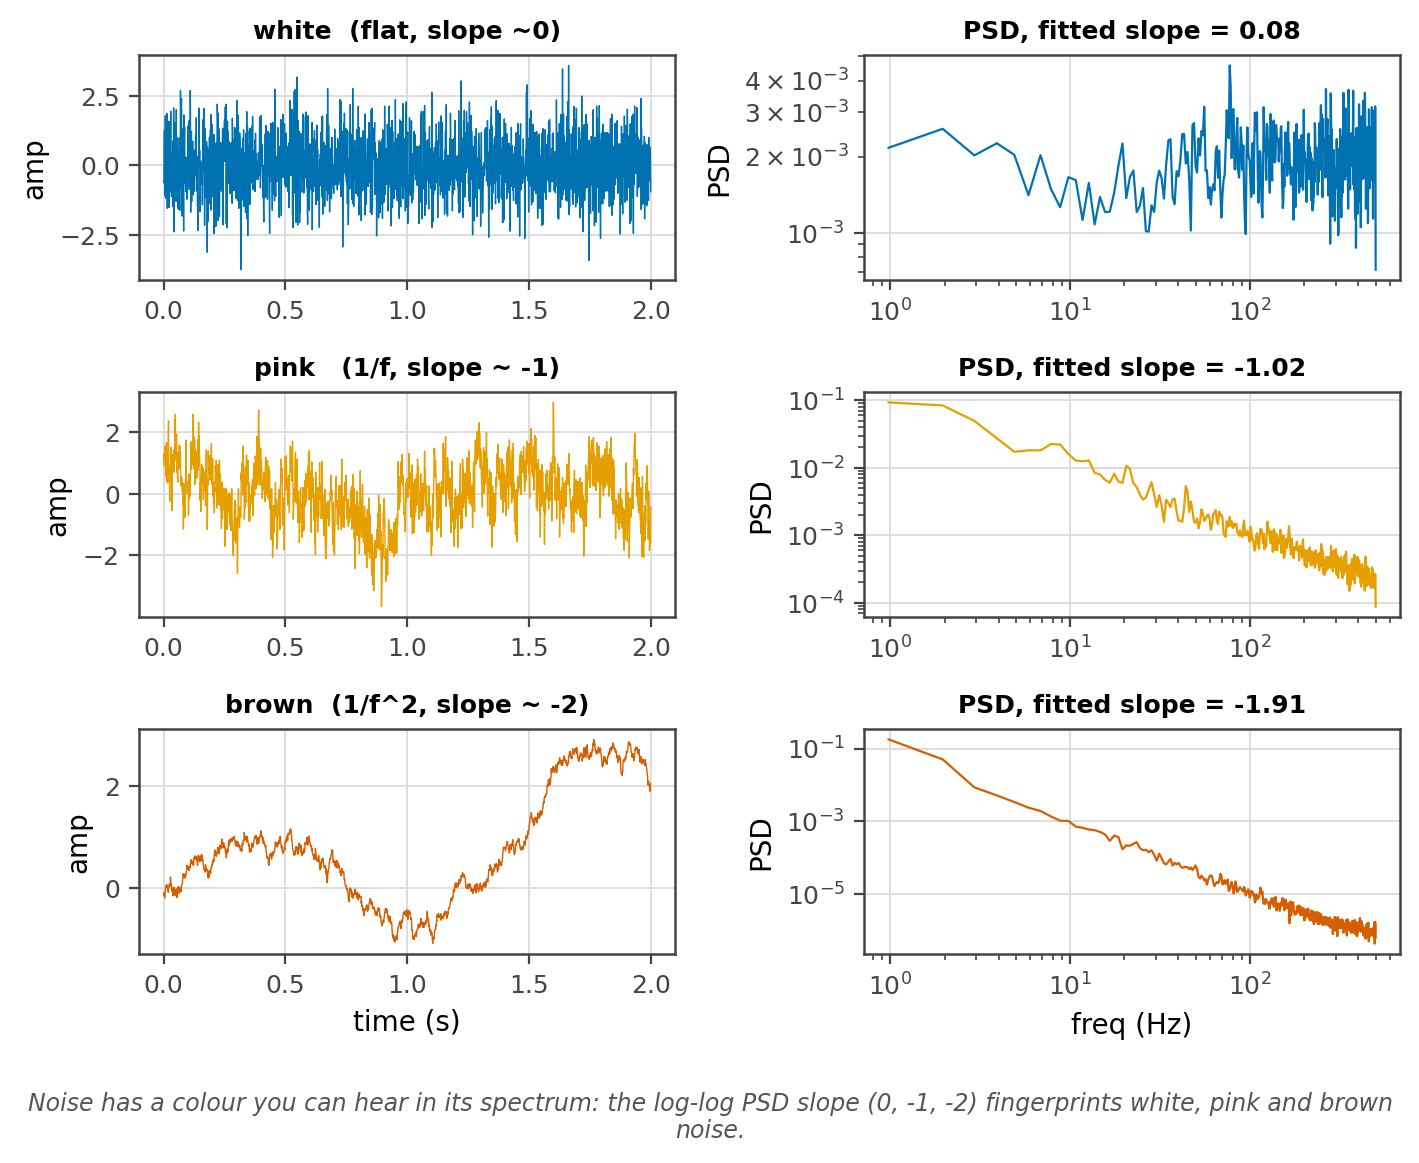

In [3]:
fs = 1000.0
N = 8192
signals = [("white  (flat, slope ~0)", bio.white(N, seed=51), bs.C['blue']),
           ("pink   (1/f, slope ~ -1)", bio.pink(N, seed=52), bs.C['orange']),
           ("brown  (1/f^2, slope ~ -2)", bio.brown(N, seed=53), bs.C['red'])]
t = np.arange(N) / fs

fig, axes = bs.newfig(w=7.2, h=5.4, nrows=3, ncols=2,
                      gridspec_kw={'width_ratios': [1, 1]})
for i, (name, x, col) in enumerate(signals):
    axes[i, 0].plot(t[:2000], x[:2000], color=col, lw=0.5)
    axes[i, 0].set_title(name, fontsize=9)
    axes[i, 0].set_ylabel("amp")
    if i == 2:
        axes[i, 0].set_xlabel("time (s)")

    f, pxx = welch(x, fs=fs, nperseg=1024)
    m = f > 0
    axes[i, 1].loglog(f[m], pxx[m], color=col, lw=0.8)
    # fit a slope in log-log over the mid band for the annotation
    band = (f > 2) & (f < 200)
    slope = np.polyfit(np.log10(f[band]), np.log10(pxx[band]), 1)[0]
    axes[i, 1].set_title(f"PSD, fitted slope = {slope:.2f}", fontsize=9)
    axes[i, 1].set_ylabel("PSD")
    if i == 2:
        axes[i, 1].set_xlabel("freq (Hz)")

bs.takeaway(fig, "Noise has a colour you can hear in its spectrum: the "
                 "log-log PSD slope (0, -1, -2) fingerprints white, pink and "
                 "brown noise.")
plt.tight_layout()
plt.show()

## 8.2  powerline ecg

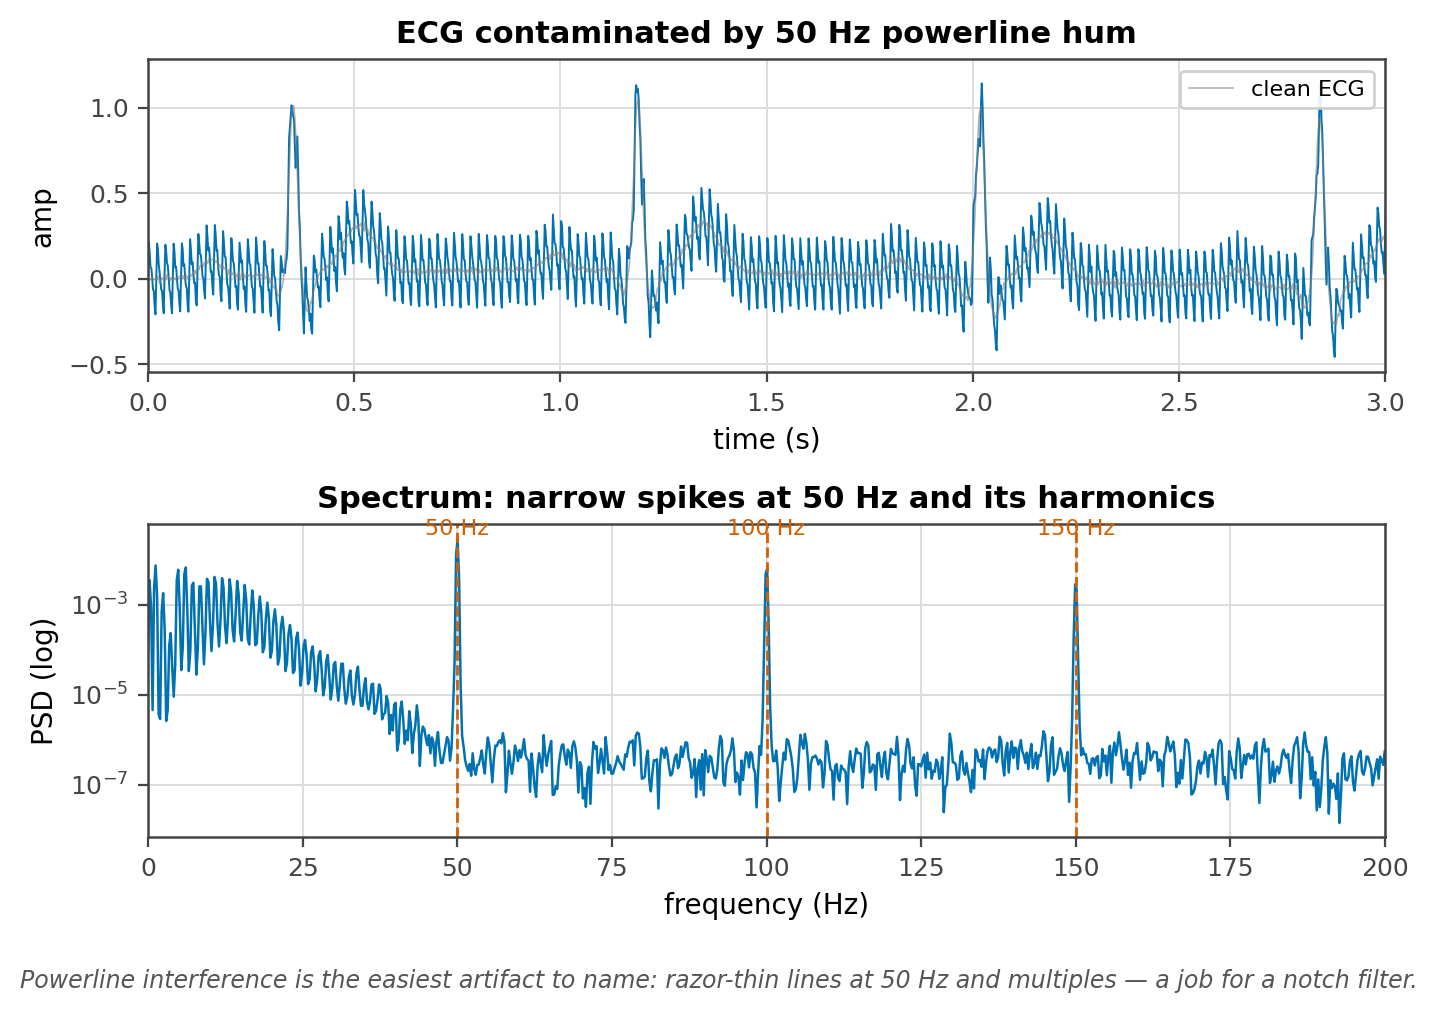

In [4]:
fs = 500.0
t, x = bio.ecg(duration=8.0, fs=fs, hr=72, noise=0.01)
n = len(x)
hum = bio.powerline(n, fs, f0=50.0, amp=0.15, harmonics=(1, 2, 3))
xn = x + hum

f, pxx = welch(xn, fs=fs, nperseg=2048)

fig, axes = bs.newfig(w=7.2, h=4.8, nrows=2, ncols=1)
axes[0].plot(t, xn, color=bs.C['blue'], lw=0.7)
axes[0].plot(t, x, color=bs.C['grey'], lw=0.6, alpha=0.6, label="clean ECG")
axes[0].set_xlim(0, 3)
axes[0].set_title("ECG contaminated by 50 Hz powerline hum")
axes[0].set_xlabel("time (s)"); axes[0].set_ylabel("amp")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].semilogy(f, pxx, color=bs.C['blue'], lw=0.9)
for h in (1, 2, 3):
    axes[1].axvline(50 * h, color=bs.C['red'], ls='--', lw=1.0)
    axes[1].annotate(f"{50*h} Hz", xy=(50 * h, np.max(pxx)),
                     ha="center", va="bottom", fontsize=8, color=bs.C['red'])
axes[1].set_xlim(0, 200)
axes[1].set_title("Spectrum: narrow spikes at 50 Hz and its harmonics")
axes[1].set_xlabel("frequency (Hz)"); axes[1].set_ylabel("PSD (log)")

bs.takeaway(fig, "Powerline interference is the easiest artifact to name: "
                 "razor-thin lines at 50 Hz and multiples — a job for a "
                 "notch filter.")
plt.tight_layout()
plt.show()

## 8.3  impulsive twin

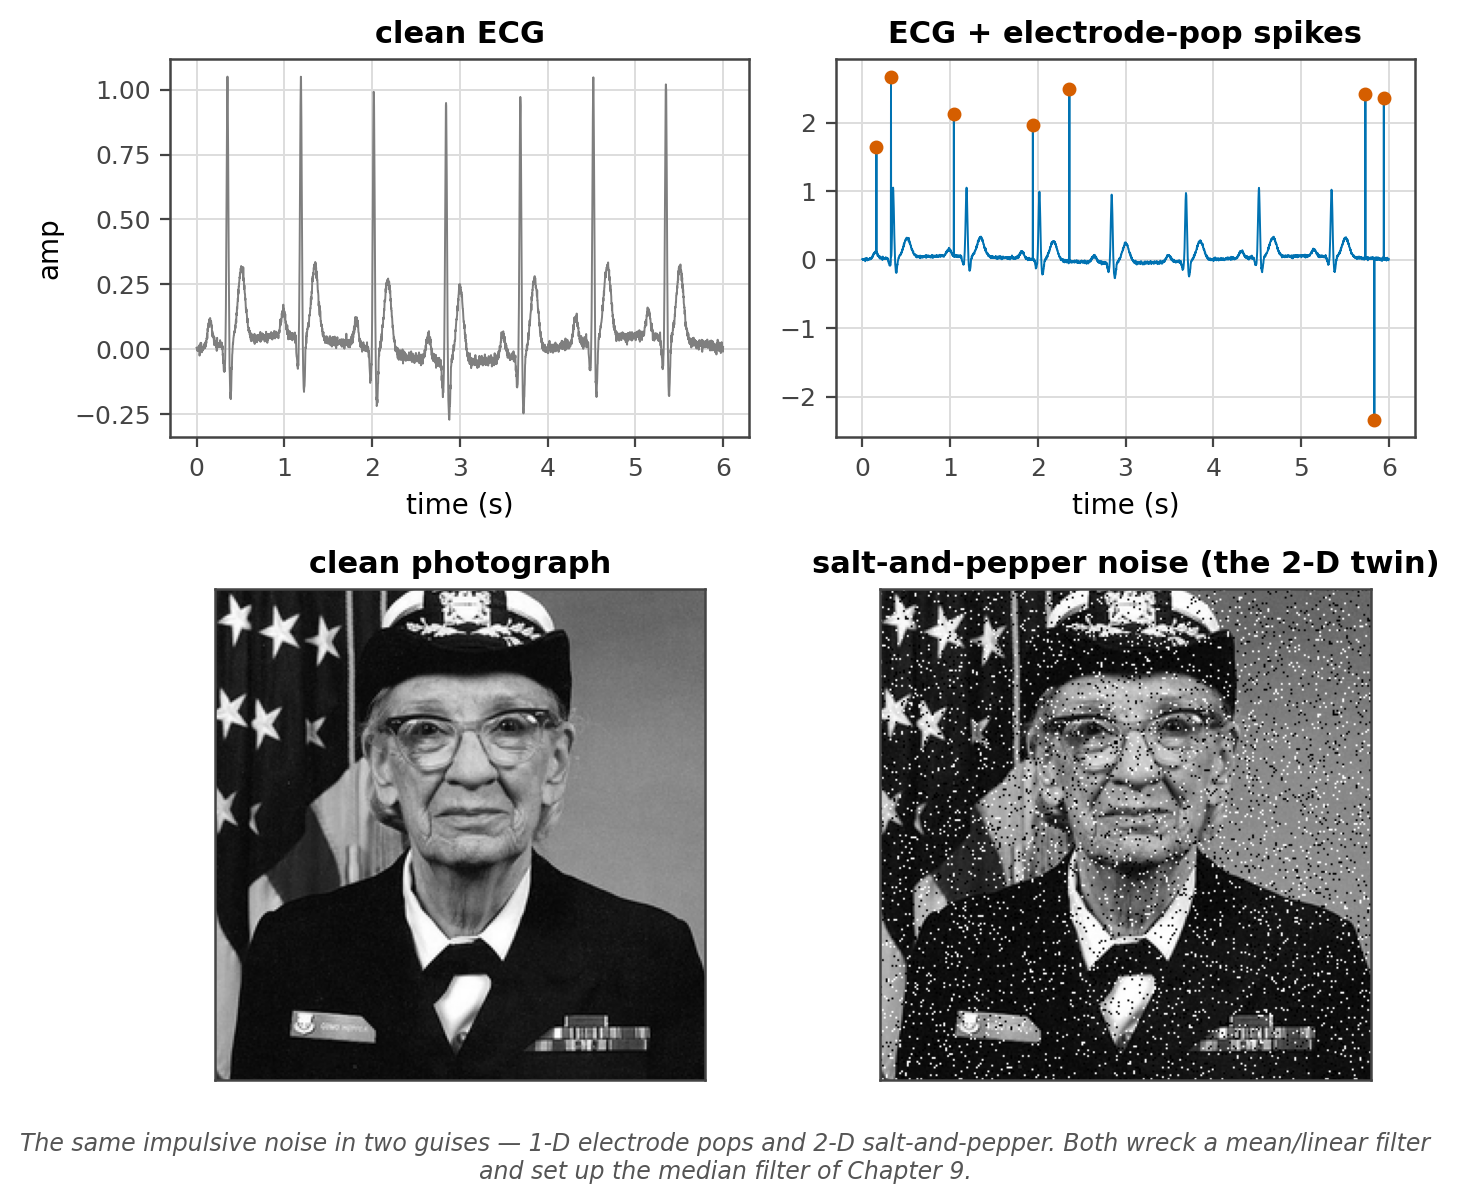

In [5]:
fig, axes = bs.newfig(w=7.2, h=5.6, nrows=2, ncols=2,
                      gridspec_kw={'height_ratios': [1, 1.3]})

# ---- 1-D: electrode-pop spikes on ECG ----
fs = 500.0
t, x = bio.ecg(duration=6.0, fs=fs, hr=72, noise=0.01)
r = np.random.default_rng(60)
xp = x.copy()
pop_idx = r.integers(0, len(x), size=8)
xp[pop_idx] += r.choice([-1, 1], size=8) * r.uniform(1.5, 3.0, size=8)

axes[0, 0].plot(t, x, color=bs.C['grey'], lw=0.7)
axes[0, 0].set_title("clean ECG")
axes[0, 0].set_ylabel("amp"); axes[0, 0].set_xlabel("time (s)")

axes[0, 1].plot(t, xp, color=bs.C['blue'], lw=0.7)
axes[0, 1].plot(t[pop_idx], xp[pop_idx], 'o', color=bs.C['red'], ms=4)
axes[0, 1].set_title("ECG + electrode-pop spikes")
axes[0, 1].set_xlabel("time (s)")

# ---- 2-D: salt-and-pepper on a photographic test image ----
img = bio.test_photo(256)
noisy = bio.salt_pepper(img, amount=0.10, seed=61)

axes[1, 0].imshow(img, cmap="gray")
axes[1, 0].set_title("clean photograph")
axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([]); axes[1, 0].grid(False)

axes[1, 1].imshow(noisy, cmap="gray")
axes[1, 1].set_title("salt-and-pepper noise (the 2-D twin)")
axes[1, 1].set_xticks([]); axes[1, 1].set_yticks([]); axes[1, 1].grid(False)

bs.takeaway(fig, "The same impulsive noise in two guises — 1-D electrode "
                 "pops and 2-D salt-and-pepper. Both wreck a mean/linear "
                 "filter and set up the median filter of Chapter 9.")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above exactly. Change a parameter and watch them move — that loop between the page and the running code is where the intuition forms.

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `randn` (white); filter to colour; `periodogram` to classify.

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Build a noise 'line-up' and classify each by its spectrum.

<details><summary>💡 Hint &amp; what you should see</summary>

White = flat PSD; pink = −3 dB/oct (1/f); brown = −6 dB/oct; powerline = a spike at 50/60 Hz + harmonics; baseline wander = very-low-frequency. Read the **PSD slope/peaks** to name each.

</details>

**2.** List the QC checks (flatline, clipping, dropout) that must precede filtering.

<details><summary>💡 Hint &amp; what you should see</summary>

flatline (dead channel), clipping (railed amplitude), dropout (missing segments), saturation, gross out-of-range amplitude. Catch these **before** filtering — a filter can't fix a dead channel, and averaging a clipped segment corrupts the result.

</details>

In [6]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch08_figures.py`.*